<a href="https://colab.research.google.com/github/Siennalee13/Siennalee13/blob/main/Module_9_Extra_EMDforMNIST_SL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# CS5012 Homework 9:: Extra Credits.
## Sienna Lee (rzd7yq)

In this assignment you are tasked with implementing the Earth Mover Distance (EMD). This implementation will be used to measure similarity between images. Specifically you will build a nearest neighbor classifier (where EMD is used as the metric) to classify MNIST Data.

## Data

The MNIST data set consists of gray-scale images of hand-drawn numeric digits - the 10 digits 0 through 9. Each image is an 8x8 2-d array where each entry in this array is a pixel in the image that can contain a gray value between 0 - 255 where 0 is black, 255 is white, and the values in between represent different gray values.

## Algorithmic Strategy

### EMD
The earth mover distance refers to a problem scenario that consists of a collection of dirt piles and a collection of holes. The goal of this problem is to find the "best" way to transport the dirt to fill the holes such that a minimum amount of work is used during transportation. Each dirt pile consists of a (location, weight) and each hole consists of a (location, weight to be filled). This is a spefici instance of a classic CS problem: the Tranportation Problem. The transportation problem has a known solutions using graph based methods. Specifically it is a min-cost-max-flow problem. Thus EMD can be solve via reduction! One need only construct the graph that represents the EMD problem then find the min-cost-max-flow.

### Application to Image Data
So how can we use a solution to the transportation problem as a similarity measure for images? Consider two 8x8 gray scale images. Each pixel is a (x,y) entry in a 2-d matrix and each pixel value is a number (weight) within the range of 0 to 255. We can transform this image comparison problem to the transportation problem as follows:

1) One image will be considered as the suppliers (dirt piles). Each dirt pile is a pixel (with a location (x,y) and a weight 0-255). The other image can be considered as the consumers (collection of holes). Each hole is a pixel (with location (x,y) and weight to be received 0-255).

*Note this transformation is intuitive for this application. If two images are similar, then each pixels value will be similar. Thus "transporting" weight w1 from pixel (x1,y1) in Image 1 to location (x1,y1) in Image 2 with a weight to be received of w2 will require no work (similar pixel location!). If the flow is not perfect and must trickle to other pixels, then a cost (penalty) based on pixel difference should be applied per flow. Furthermore, it can be shown that with certain assumptions EMD meets the requirements of a distance metric (it will even satisfy the triangle inequality).*  

__Further Note: You will have creative license in determining how the locations & weights are computed based on the image. There are many ways to design this problem. Bonus Points will be awarded to the groups with the highest classification accuracy. See details in Task 6.__


2) Set up a graph to solve this transportation problem using networkx. The key here is to design the graph to represent this problem correctly. That is, you must complete the reduction: What do the nodes represent? What do the edges represent? What are the capacities and the weights?

3) Use the min-cost-max-flow solution in network x to compute the similarity between images.


Follow the instructions herein and complete the numbered tasks, exercises, and questions below.



In [1]:
!pip install imutils
!pip install opencv-python
!pip install --upgrade google-api-python-client

In [2]:
# import the necessary packages
!pip install scikit-image
!pip install networkx
from __future__ import print_function
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import classification_report
from sklearn import datasets
from skimage import exposure
import numpy as np
import imutils
import cv2
#from google.colab.patches import cv2_imshow
import sklearn
import matplotlib.pyplot as plt
import math
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.flow import maximum_flow

from sklearn.model_selection import train_test_split

#Loading the Data

Lets load and inspect the data.

training data points: 1212
validation data points: 135
testing data points: 450
(1212, 64)
The image label of index 200 is 5.


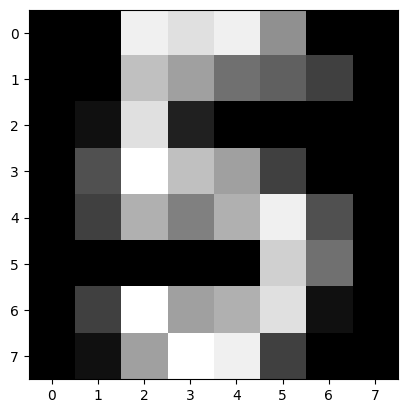

In [3]:
def image_show(i, data, label):
    x = data[i] # get the vectorized image
    x = x.reshape((8,8)) # reshape it into 28x28 format
    print('The image label of index %d is %d.' %(i, label[i]))
    plt.imshow(x, cmap='gray') # show the image

# load the MNIST digits dataset
mnist = datasets.load_digits()

# take the MNIST data and construct the training and testing split, using 75% of the
# data for training and 25% for testing
(trainData, testData, trainLabels, testLabels) = train_test_split(np.array(mnist.data),
                                                                  mnist.target, test_size=0.25, random_state=42)

# now, let's take 10% of the training data and use that for validation
(trainData, valData, trainLabels, valLabels) = train_test_split(trainData, trainLabels,
                                                                test_size=0.1, random_state=84)

# show the sizes of each data split
print("training data points: {}".format(len(trainLabels)))
print("validation data points: {}".format(len(valLabels)))
print("testing data points: {}".format(len(testLabels)))

print(trainData.shape)
image_show(200, trainData, trainLabels)

# Nearest Neighbors

Below is an example of how to find nearest neighbors using sklearn. The metric chosen below is the Manhattan Distance. The training data is supplied as a vector and thus the Euclidean distance can be used to measure the similarity between vectorized images.

In [4]:
#a = [1,2,3,4]
#b = [5,2,3,4]
#c = [2,3,3,4]

#a->b: 4
#a->c: 2

#a->b: 1
#a->c: 2

In [5]:
nbrs = NearestNeighbors(n_neighbors=2, algorithm='ball_tree', metric='euclidean').fit(trainData)   # Build "similarity search model". (trainData = all MNIST images)
distances, indices = nbrs.kneighbors(trainData)        # Find nearest neighbors
print(indices)
i = 0
image1 = trainData[indices[i,0]]
image1

[[   0 1119]
 [   1  767]
 [   2  681]
 ...
 [1209  262]
 [1210  962]
 [1211  400]]


array([ 0.,  0.,  6., 16., 16., 11.,  0.,  0.,  0.,  1., 16.,  8.,  8.,
       16.,  6.,  0.,  0.,  0.,  8., 16., 14., 16., 11.,  0.,  0.,  0.,
        1.,  4.,  3., 10.,  8.,  0.,  0.,  0.,  0.,  0.,  0.,  9.,  7.,
        0.,  0.,  0.,  0.,  0.,  1., 14.,  1.,  0.,  0.,  0.,  4.,  7.,
       11.,  9.,  0.,  0.,  0.,  0.,  9., 16., 10.,  1.,  0.,  0.])

In [6]:
A = np.reshape(image1, (8, 8))   # A is 8x8 grid now
A

array([[ 0.,  0.,  6., 16., 16., 11.,  0.,  0.],
       [ 0.,  1., 16.,  8.,  8., 16.,  6.,  0.],
       [ 0.,  0.,  8., 16., 14., 16., 11.,  0.],
       [ 0.,  0.,  1.,  4.,  3., 10.,  8.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  9.,  7.,  0.],
       [ 0.,  0.,  0.,  0.,  1., 14.,  1.,  0.],
       [ 0.,  0.,  4.,  7., 11.,  9.,  0.,  0.],
       [ 0.,  0.,  9., 16., 10.,  1.,  0.,  0.]])

In [7]:
A[0,3]

np.float64(16.0)

Original Image


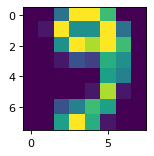

Nearest Neighbor Image


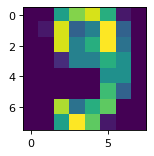

Original Image


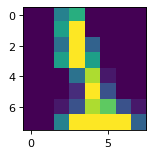

Nearest Neighbor Image


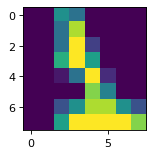

Original Image


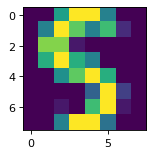

Nearest Neighbor Image


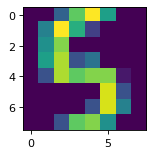

Original Image


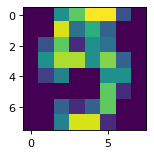

Nearest Neighbor Image


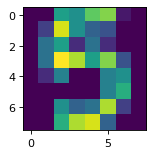

Original Image


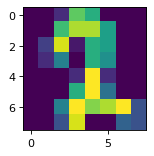

Nearest Neighbor Image


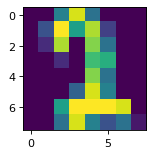

In [8]:
# Build nearest neighbor model
nbrs = NearestNeighbors(n_neighbors=2, algorithm='ball_tree', metric='euclidean').fit(trainData)
distances, indices = nbrs.kneighbors(trainData)
#print(indices)

# loop over first few  digits and compare to nearest neighbor
# loop through first 5 images
for i in range(5):
    # grab the image and classify it
    image1 = trainData[indices[i,0]]                   # original, itself
    image2 = trainData[indices[i,1]]                   # closest image
    image1 = image1.reshape((8, 8)).astype("uint8")    # convert to 8x8 images
    image2 = image2.reshape((8, 8)).astype("uint8")    # convert to 8x8 images
    image1 = exposure.rescale_intensity(image1, out_range=(0, 255))    # Rescale brightness(contrast)
    image2 = exposure.rescale_intensity(image2, out_range=(0, 255))    # Rescale brightness(contrast)
    #image1 = imutils.resize(image1, width=32, inter=cv2.INTER_CUBIC)  # (Optional)resize
    #image2 = imutils.resize(image2, width=32, inter=cv2.INTER_CUBIC)  # (Optional)resize
    print("Original Image")
    fig = plt.figure(figsize=(2, 2), dpi=80)
    plt.imshow( image1)                                 # plot original image
    plt.show()                                          # show nearest neighbor image
    print("Nearest Neighbor Image")
    fig = plt.figure(figsize=(2, 2), dpi=80)
    plt.imshow( image2)
    plt.show()

# Task 1: Conceptual Explanation and Reduction (20pts)

---


Reduce Image Comparison to the EMD / Transportation Problem. Define all variables and explain with detail, eg, nodes, edges, weights, capacities, flow, cost, ... .

Answer:
For this assignment, I reduce image comparison to the Earth Mover’s Distance transportation problem by treating each image as a distribution of pixel “mass.” Each MNIST image is an 8×8 grayscale image, where each pixel has a spatial location and an intensity value. Image 1 is treated as the supplier(original) image, and Image 2 is treated as the consumer(closest) image.
The transportation problem is represented using a directed graph. The graph contains a source node, supplier nodes from image 1, consumer nodes from image 2, and a sink node.
Edges from the source to the supplier nodes have capacities equal to the available weight in each image 1 region and cost 0. Edges from supplier nodes to consumer nodes represnet moving pixel mass from image 1 to image 2. These egdes have costs based on the spatial distance between locations, such as Manhattan distance, and capacities large enough to allow flow. Edges from consumer nodes to the sink have capacities equal to the required weight in each image 2 region and cost 0.
For this setup, flow represents the amount of pixel mass transported from one image region to another. The cost of transporting flow is the amount of mass moved multiplied by the distance between the two locations.Hence, the Earth Mover's Distance is the minimum total cost required to transform the mass distribution of image 1 into the mass distribution of image 2.If their pixel mass is located in very different regions, the total cost will be larger. This makes EMD a meaninggul distance metric for comparing handwritten digit images.

# Task 2: Generate Features (40pts)
Within your answer to Task 1, you should have identified how to compute locations and weights for each image. Define / implement a function computeWorkFeatures(img1) that computes and returns a list of (location, weight) pairs. Within this context the location should represent the sub-image index for which the weight is computed. For example, if you split the image into quarters or quadrants you will have for locations: (0,0), (0,1), (1,0) and (1,1) and the corresponding weights for each quadrant will be related to the values of the pixels within that quadrant.   

In [9]:
#Lets define our own distance metric

# I used the Manhattan Distance as the subimage location penalty measure.
def calc_distance(p1, p2):
    return abs(p1[0]-p2[0])+abs(p1[1]-p2[1])

# Hint: Note the weights and capacities on the graph should be INTs! Module networkx
# can succomb to some wonky rounding errors when floating point values are used!

# Hint: I also suggest renormalizing the weights of both images to be similar
# so that min costs are comparable. (Otherwise the costs will skew downward for darker images.)
# I renormalized to a total weight of 100 and rounded
# the individual weights so that they were ints.

def computeWorkFeatures(img1):
    '''
    Input: img1
    An input image that is 8x8.

    This function subdivides the image into subimages, assigns coordinates /
    locations to each subimage based on spatial location, then computes the total
    pixel value for each subimage.

    returns:  emdFeatureList  ...  example format shown below though feel free to organize as you see fit ....

    emdFeatureList = [ [ subImageCoord,  totalPixWeight   ]   ,   [ (0,0), 123  ] ,      ... , [ (3,3) , 210 ]     ]

    '''
    img1 = img1.reshape((8, 8))
    emdFeatureList =[]
# divide image into 2 rows x 2 columns of subimages
    for row_block in range(2):
        for col_block in range(2):
            # select each 4 x4 quadrant
            subimage = img1[row_block*4:(row_block+1)*4, col_block*4:(col_block+1)*4]
            subimageCoord = (row_block, col_block)

            # weight = total pixel intensity in that quadrant
            weight = int(np.sum(subimage))

            # location = quadrant location
            location = subimageCoord

            emdFeatureList.append([location, weight])
    return emdFeatureList

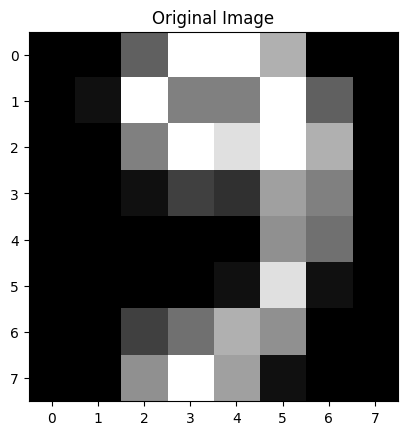

[[(0, 0), 76], [(0, 1), 119], [(1, 0), 36], [(1, 1), 63]]


In [10]:
img = trainData[0].reshape((8, 8))
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.show()

print(computeWorkFeatures(trainData[0]))


# Task 3: Implement the Earth Mover Distance (100pts)
Implement a function *emd(img1,img2,verbose = False)* that computes and returns the Earth Mover Distance between img1 and img2 (using features computed from *computeWorkFeatures* ). The distance will be computed via reduction and using a min-cost-max-flow solution from networkx.

1. Compute location weight pairs for img1 and img2
2. Construct the graph to compute the EMD from img1 to img2.
3. Solve min-cost-max-flow using *nx.max_flow_min_cost*
4. Display graph if verbose == True

In [11]:
def emd(img1,img2, verbose = False):

    '''
    Input: img1, img2

    Both are image vectors from the trainData Structure. These will be reformated to 8x8

    returns:  minCost  ...  example format shown below though feel free to organize as you see fit ....

    '''
    mincost = -1
    image1 = img1.reshape((8, 8)).astype("uint8")
    image2 = img2.reshape((8, 8)).astype("uint8")
    emdFeatListImg1 = computeWorkFeatures(image1)
    emdFeatListImg2 = computeWorkFeatures(image2)

    '''
    Construct the directed bipartite graph with added source and sink.
    '''
    # Hint: I suggest using a DiGraph and adding a source and a sink to the Bipartite Graph.

    # INSERT CODE HERE :)
    # Create directed graph
    G = nx.DiGraph()

    Source = "Source"
    Sink = "Sink"

    # Total weight in each image
    total1 = sum([w for loc, w in emdFeatListImg1])
    total2 = sum([w for loc, w in emdFeatListImg2])

    # Use the smaller total so the flow problem is feasible
    total_flow = min(total1, total2)

    # Add edges from Source to Image 1 feature nodes
    for i, (loc1, weight1) in enumerate(emdFeatListImg1):
        supply_node = "img1_" + str(i)

        G.add_node(supply_node)
        G.add_edge(Source, supply_node, capacity=int(weight1), weight=0)
     # Add edges from Image 2 feature nodes to Sink
    for j, (loc2, weight2) in enumerate(emdFeatListImg2):
        demand_node = "img2_" + str(j)
        G.add_edge(demand_node, Sink, capacity=int(weight2), weight=0)

    # Add edges between Image 1 nodes and Image 2 nodes
    for i, (loc1, weight1) in enumerate(emdFeatListImg1):
        supply_node = "img1_" + str(i)

        for j, (loc2, weight2) in enumerate(emdFeatListImg2):
            demand_node = "img2_" + str(j)

            distance_cost = calc_distance(loc1, loc2)

            G.add_edge(
                supply_node,
                demand_node,
                capacity=int(total_flow),
                weight=int(distance_cost)
            )


    # Compute min-cost max-flow
    mincostFlow = nx.max_flow_min_cost(G, Source, Sink)
    mincost = nx.cost_of_flow(G, mincostFlow)

    '''
    Draw resulting graph using bipartite positioning
    '''

    if verbose:
        # First Identify which nodes are sources and then use networkx draw.
        # I suggest drawing using nx.bipartite_layout
        pos = nx.spring_layout(G)
        nx.draw(G, pos, with_labels=True, node_size=900, font_size=8)

        edge_labels = nx.get_edge_attributes(G, "weight")
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

        plt.show()
    return mincost



#Task 4 Qualitative Analysis (20pts)
Does this method work well for this application? Lets investigate! Use the code snippet below to visually identify some nearest neighbor pairs. Are the results intuitive? Does your method work as expected? as desired? Explain why or why not. If the results are unexpected, you may need to further investigate your implmentation and assure there are no bugs or conceptual error.




Answer: Overall, the EMD-based nearest neighbor approach performs reasonably well for this task. When visually comparing the original images with their nearest neighbors, most pairs appear intuitive, as the matched digits share similar shapes and spatial patterns of pixel intensity. This indicates that the EMD metric is effectively capturing meaningful structural similarity between images.

This behavior is expected because EMD accounts for spatial movement of pixel mass rather than relying on strict pixel-by-pixel comparisons. As a result, it is more tolerant to small shifts or distortions in handwritten digits, which commonly occur in the MNIST dataset.

That said, the method is not perfect. In some cases, the nearest neighbor may not look visually identical, particularly when different digits exhibit similar overall intensity distributions across regions. This limitation is likely due to the feature representation, where the image is summarized into a small number of subregions, leading to some loss of fine-grained detail.

Overall, the results are largely intuitive and align with expectations. However, performance is sensitive to how features are constructed. Increasing the number of subregions or refining the representation could better preserve spatial detail and further improve matching accuracy.

Original Image


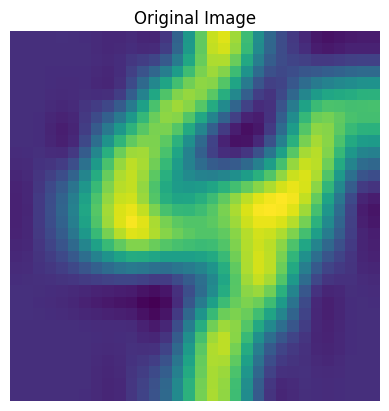

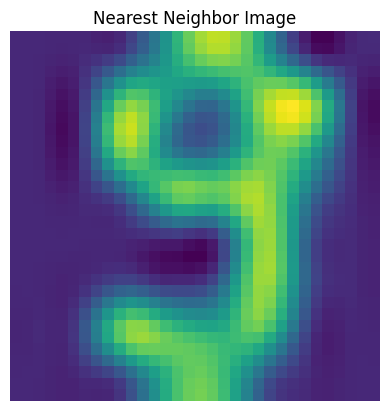

Original Image


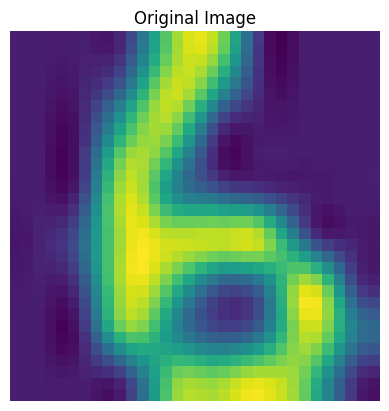

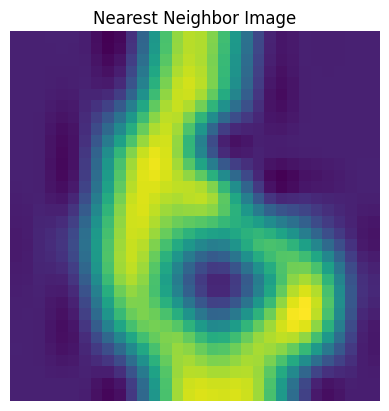

Original Image


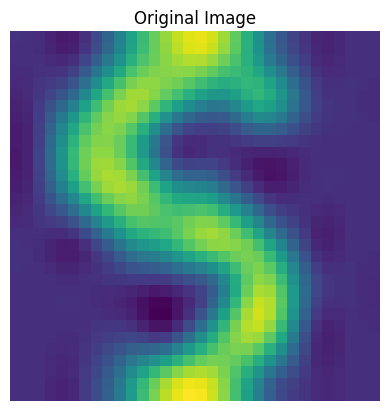

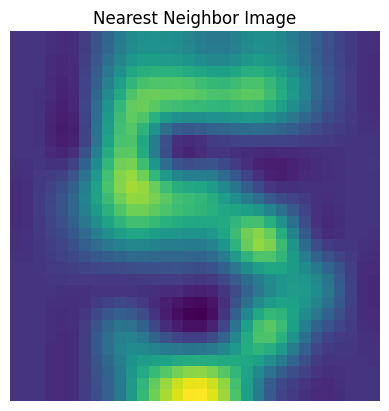

Original Image


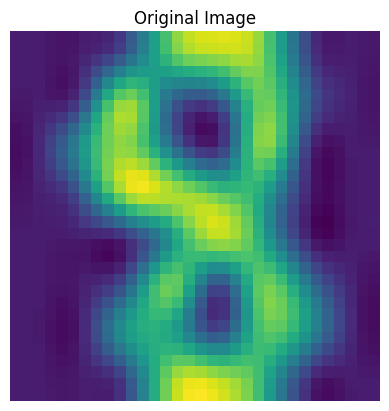

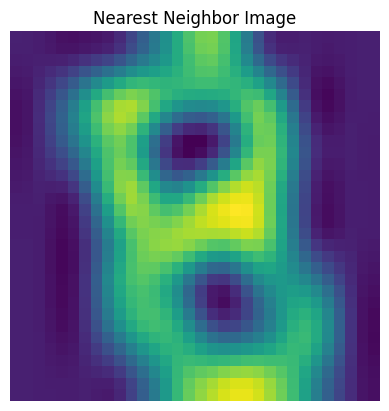

Original Image


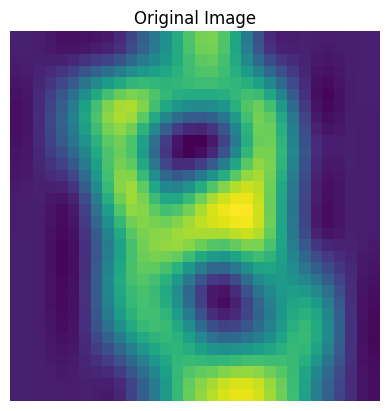

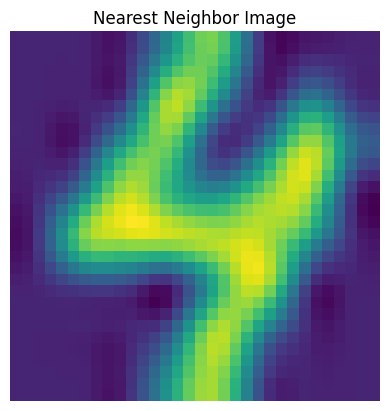

Original Image


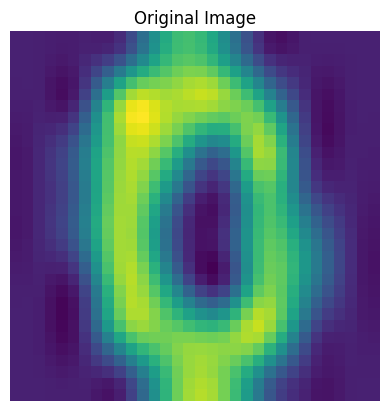

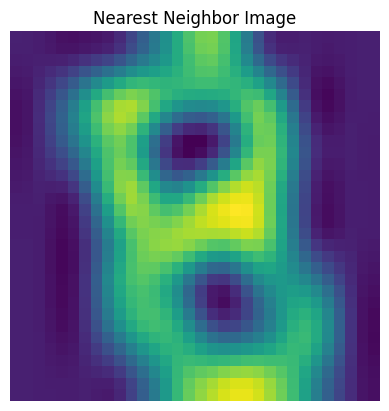

Original Image


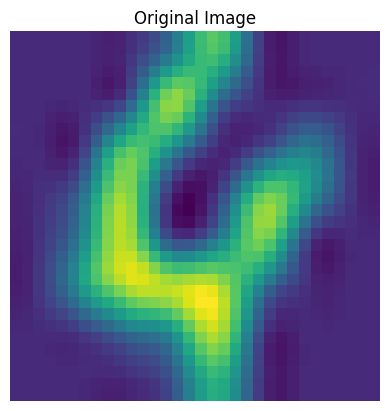

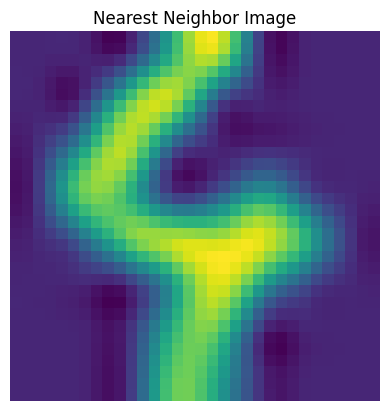

Original Image


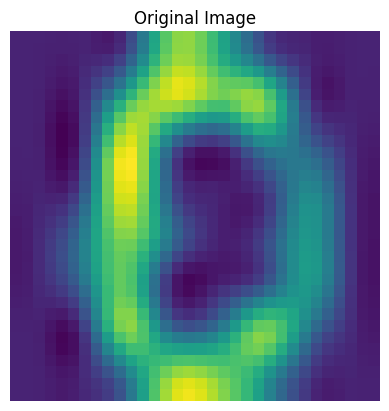

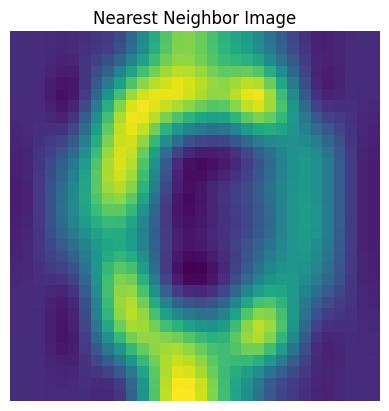

Original Image


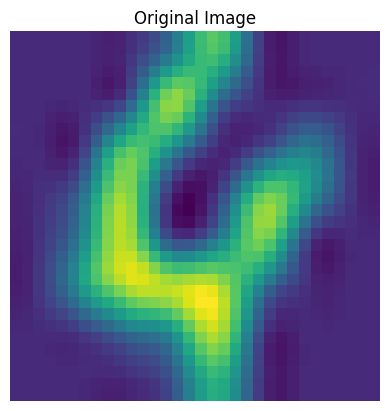

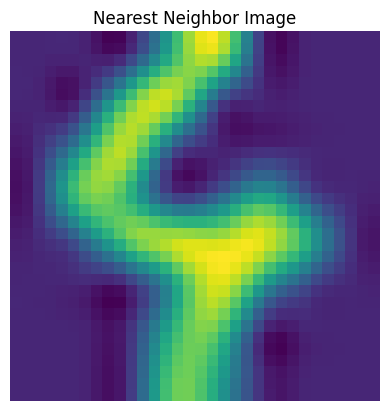

Original Image


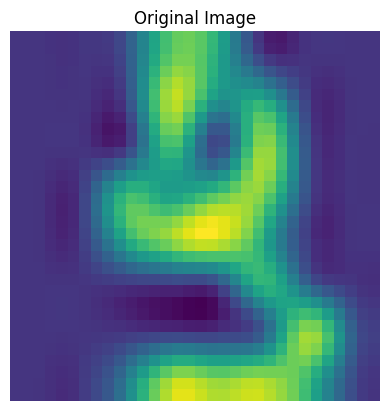

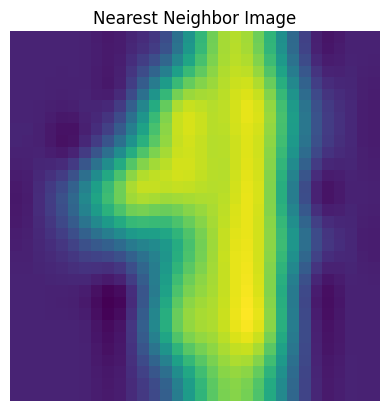

In [12]:
# Computes nearest neighbor for first 200 samples and visually displays the results for the first 10

nbrs = NearestNeighbors(n_neighbors=2, algorithm='ball_tree', metric=emd).fit(trainData[:200,:])
distances, indices = nbrs.kneighbors(trainData[:200,:])
#print(distances)
#print(indices)

# loop over first few  digits and compare to nearest neighbor
for i in range(10):
    # grab the image and classify it
    image1 = trainData[indices[i,0]]
    image2 = trainData[indices[i,1]]
    image1 = image1.reshape((8, 8)).astype("uint8")
    image2 = image2.reshape((8, 8)).astype("uint8")
    image1 = exposure.rescale_intensity(image1, out_range=(0, 255))
    image2 = exposure.rescale_intensity(image2, out_range=(0, 255))
    image1 = imutils.resize(image1, width=32, inter=cv2.INTER_CUBIC)
    image2 = imutils.resize(image2, width=32, inter=cv2.INTER_CUBIC)
    print("Original Image")
    plt.imshow(image1)
    plt.title("Original Image")
    plt.axis('off')
    plt.show()

    plt.imshow(image2)
    plt.title("Nearest Neighbor Image")
    plt.axis('off')
    plt.show()


#Task 5. Use EMD for Classification (20pts)

Implement a nearest neighbor classifier using *KNeighborsClassifier(...)*. Provide your metric as an input parameter, i.e., *metric=emd*. Try for k = 1 and k = 3. What is the classification accuracy of your implementation?

Consider how you might improve the accuracy. Given your qualitative analysis and your understanding of the "driving" factors and features of this algorithm, what updates or changes would you investigate to improve results? Hint: How did you compute the locations and weights? Were these values normalized? How many subimages / locations did you use for each image? ... Explain and justify your reasoning here given your understanding of the data and the methodology. If you have time, try to improve your results!

Answer: The EMD-based nearest neighbor classifier achieved 32.59% accuracy for k = 1 and 34.81% for k = 3, with k = 3 performing slightly better. While the results are reasonable given the approach, the overall accuracy is relatively low, suggesting that the current feature representation is too coarse.

The main limitation comes from how the image is summarized. By reducing each image into only a few subregions, some fine-grained spatial details are lost. As a result, different digits can end up with similar weight distributions across regions, even when their shapes are clearly different.

To improve performance, I would first increase the number of subimages (e.g., moving from 4 quadrants to a 4×4 grid). This would preserve more spatial structure and allow the EMD metric to better distinguish between digits. I would also normalize the weights so that each image has the same total mass, which would make comparisons more consistent across images with different overall brightness.

Additionally, I would experiment with a wider range of k values to see if a slightly larger neighborhood improves stability. Overall, the method is conceptually sound, but the results highlight that feature construction plays a critical role in the effectiveness of the classifier.

In [13]:
# initialize the values of k for our k-Nearest Neighbor classifier along with the
# list of accuracies for each value of k
kVals = [1,3]
accuracies = []

# loop over various values of `k` for the k-Nearest Neighbor classifier
for k in kVals:
# train the k-Nearest Neighbor classifier with the current value of `k`
	model = KNeighborsClassifier(n_neighbors=k, algorithm='ball_tree', metric=emd)
	model.fit(trainData, trainLabels)

# evaluate the model and update the accuracies list
	score = model.score(valData, valLabels)
	print("k=%d, accuracy=%.2f%%" % (k, score * 100))
	accuracies.append(score)

# find the value of k that has the largest accuracy
i = int(np.argmax(accuracies))
print("k=%d achieved highest accuracy of %.2f%% on validation data" % (kVals[i],
	accuracies[i] * 100))

k=1, accuracy=30.37%
k=3, accuracy=35.56%
k=3 achieved highest accuracy of 35.56% on validation data
